In [66]:
# Cell 1: Imports
import numpy as np
from scipy.linalg import svd, solve
from scipy.optimize import minimize
from sklearn.linear_model import LinearRegression

In [78]:
# Cell 2: LSSM with corrected SVD (Gamma_f from right singular vectors)
class LSSM:
    """
    Linear State-Space Model:
        x_{k+1} = A x_k + B u_k + w_k
        y_k     = C x_k + v_k
    with w_k ~ N(0, Psi), v_k ~ N(0, Gamma).
    """

    def __init__(self, state_dim):
        self.state_dim = state_dim
        self.A = None
        self.B = None
        self.C = None
        self.Psi = None
        self.Gamma = None
        self.n_inputs = None
        self.n_outputs = None

    def _stabilize(self, A, max_eig=0.999):
        """Project A onto the set of stable matrices by shrinking eigenvalues."""
        eigvals, eigvecs = np.linalg.eig(A)
        eigvals_stable = np.where(np.abs(eigvals) > max_eig,
                                  eigvals / np.abs(eigvals) * max_eig,
                                  eigvals)
        A_stable = (eigvecs @ np.diag(eigvals_stable) @ np.linalg.inv(eigvecs)).real
        return A_stable

    def fit(self, U, Y, horizon=None, pem_refine=True, pem_iters=50, verbose=True):
        """
        Fit the model via subspace identification (CCA-based) followed
        by optional PEM refinement.
        """
        N, m = U.shape
        _, p = Y.shape
        self.n_inputs = m
        self.n_outputs = p
        d = self.state_dim

        if verbose:
            print("=" * 55)
            print("  LSSM FIT")
            print("=" * 55)
            print(f"  Data: {N} samples, {m} inputs, {p} outputs")
            print(f"  State dimension: {d}")
            print(f"  Output range: [{Y.min():.4f}, {Y.max():.4f}]")
            print(f"  Input range:  [{U.min():.4f}, {U.max():.4f}]")

        # --- Default horizon ---
        if horizon is None:
            horizon = min(15, N // 3)
        L = horizon

        if verbose:
            print(f"  Horizon (L): {L}")
            print()

        # --- Build regressor (past data) and target (future outputs) ---
        J = N - 2 * L + 1

        if verbose:
            print("  [1/5] Building past/future data matrices...")

        P = np.zeros((J, L * (m + p)))
        for i in range(L):
            P[:, i * m:(i + 1) * m] = U[i:i + J, :]
            P[:, L * m + i * p:L * m + (i + 1) * p] = Y[i:i + J, :]

        F = np.zeros((J, L * p))
        for i in range(L):
            F[:, i * p:(i + 1) * p] = Y[L + i:L + i + J, :]

        if verbose:
            print(f"        Past matrix P: {P.shape}")
            print(f"        Future output matrix F: {F.shape}")
            print()

        # --- Step 1: Regress F on P (ridge-regularized) ---
        if verbose:
            print("  [2/5] Regressing future outputs on past data (ridge)...")

        P_mean = np.mean(P, axis=0)
        F_mean = np.mean(F, axis=0)
        P_centered = P - P_mean
        F_centered = F - F_mean

        alpha = 1e-3 * np.trace(P_centered.T @ P_centered) / P_centered.shape[1]
        PP = P_centered.T @ P_centered + alpha * np.eye(P_centered.shape[1])
        PF = P_centered.T @ F_centered
        beta = solve(PP, PF, assume_a='pos')

        F_pred = P_centered @ beta

        if verbose:
            print(f"        Beta shape: {beta.shape}")
            print(f"        Variance explained by past: "
                  f"{1 - np.var(F_centered - F_pred) / np.var(F_centered):.2%}")
            print()

        # --- Step 2: SVD of predictions to get observability matrix ---
        if verbose:
            print("  [3/5] SVD of predicted future outputs...")

        U_svd, S_svd, Vt = svd(F_pred, full_matrices=False)

        # Gamma_f from RIGHT singular vectors: shape (L*p x d)
        Gamma_f = Vt[:d, :].T @ np.diag(np.sqrt(S_svd[:d]))

        if verbose:
            print(f"        Gamma_f shape: {Gamma_f.shape}")
            print(f"        Top {min(10, len(S_svd))} singular values: "
                  f"{np.array2string(S_svd[:min(10, len(S_svd))], precision=4, suppress_small=True)}")
            print()

        # --- Step 3: Extract C ---
        self.C = Gamma_f[:p, :]

        if verbose:
            print("        C matrix extracted")
            print(f"        C shape: {self.C.shape}")
            print()

        # --- Step 4: Extract A ---
        if verbose:
            print("  [4/5] Extracting A from observability matrix...")

        Gamma_minus = Gamma_f[:-p, :]
        Gamma_plus  = Gamma_f[p:, :]
        A_raw = np.linalg.lstsq(Gamma_minus, Gamma_plus, rcond=None)[0]
        self.A = self._stabilize(A_raw, max_eig=0.999)

        if verbose:
            eigvals = np.linalg.eigvals(A_raw)
            eigvals_stable = np.linalg.eigvals(self.A)
            print(f"        A shape: {self.A.shape}")
            print(f"        Max |eig(A_raw)|: {np.max(np.abs(eigvals)):.4f}")
            print(f"        Max |eig(A_stabilized)|: {np.max(np.abs(eigvals_stable)):.4f}")
            print()

        # --- Step 5: Recover state sequence and estimate B ---
        if verbose:
            print("  [5/5] Estimating state sequence and B...")

        Gamma_pinv = np.linalg.pinv(Gamma_f)  # (d x L*p)
        X = Gamma_pinv @ F_pred.T              # (d x L*p) @ (L*p x J) = (d x J)

        if verbose:
            print(f"        State sequence X shape: {X.shape[0]} x {X.shape[1]}")
            print(f"        Mean state norm: {np.mean(np.linalg.norm(X, axis=0)):.3f}")

        U_k = U[L:L + J, :]
        X_curr = X[:, :-1]
        X_next = X[:, 1:]
        U_curr = U_k[:-1, :]

        Y_reg = (X_next - self.A @ X_curr).T
        reg = LinearRegression(fit_intercept=False)
        reg.fit(U_curr, Y_reg)
        self.B = reg.coef_

        if verbose:
            print(f"        B shape: {self.B.shape}")
            print(f"        R² score: {reg.score(U_curr, Y_reg):.4f}")

        reg_eps = 1e-8
        W_res = Y_reg - U_curr @ self.B.T
        self.Psi = np.cov(W_res, rowvar=False) + reg_eps * np.eye(d)

        Y_cols = Y[L:L + J, :]
        V_res = Y_cols - X.T @ self.C.T
        self.Gamma = np.cov(V_res, rowvar=False) + reg_eps * np.eye(p)

        if verbose:
            print(f"        Process noise trace  tr(Ψ): {np.trace(self.Psi):.6f}")
            print(f"        Measurement noise trace tr(Γ): {np.trace(self.Gamma):.6f}")
            print()

        # --- Step 6: Optional PEM refinement ---
        if pem_refine:
            if verbose:
                print("  [PEM] Refining via prediction error minimization...")
                print(f"         Max iterations: {pem_iters}")
            self._pem_refine(U, Y, max_iter=pem_iters, verbose=verbose)

        if verbose:
            print("=" * 55)
            print("  FIT COMPLETE")
            print("=" * 55)

        return self

    def _pem_refine(self, U, Y, max_iter=50, verbose=True):
        """Refine A, B, C via prediction error minimization (L-BFGS)."""
        m, p = self.n_inputs, self.n_outputs
        d = self.state_dim

        def pack(A, B, C):
            return np.concatenate([A.ravel(), B.ravel(), C.ravel()])

        def unpack(theta):
            A = theta[:d * d].reshape(d, d)
            B = theta[d * d:d * d + d * m].reshape(d, m)
            C = theta[d * d + d * m:].reshape(p, d)
            return A, B, C

        theta0 = pack(self.A, self.B, self.C)

        def init_state(U_prefix):
            if len(U_prefix) < d:
                return np.zeros(d)
            x = np.zeros(d)
            for t in range(len(U_prefix)):
                x = self.A @ x + self.B @ U_prefix[t]
            return x

        self._pem_iter = 0
        self._pem_best = np.inf

        def prediction_error(theta):
            A, B, C = unpack(theta)
            A = self._stabilize(A, max_eig=0.999)
            init_len = min(20, len(U) // 4)
            x = init_state(U[:init_len])
            err = 0.0
            for t in range(init_len, len(U)):
                y_pred = C @ x
                err += np.sum((Y[t] - y_pred) ** 2)
                x = A @ x + B @ U[t]
            return err / (len(U) - init_len)

        def callback(theta):
            self._pem_iter += 1
            err = prediction_error(theta)
            if err < self._pem_best:
                self._pem_best = err
            if verbose and self._pem_iter % 10 == 0:
                A, B, C = unpack(theta)
                A = self._stabilize(A, max_eig=0.999)
                eigvals = np.abs(np.linalg.eigvals(A))
                print(f"         Iter {self._pem_iter:3d}: MSE = {err:.6f}, "
                      f"max|eig(A)| = {np.max(eigvals):.4f}")

        if verbose:
            initial_err = prediction_error(theta0)
            print(f"         Initial PEM error: {initial_err:.6f}")

        res = minimize(prediction_error, theta0, method='L-BFGS-B',
                       options={'maxiter': max_iter, 'disp': False},
                       callback=callback)

        if res.success or res.fun < prediction_error(theta0):
            self.A, self.B, self.C = unpack(res.x)
            self.A = self._stabilize(self.A, max_eig=0.999)

            init_len = min(20, len(U) // 4)
            x0 = init_state(U[:init_len])
            x = np.zeros((len(U) + 1, d))
            x[init_len] = x0
            for t in range(init_len, len(U)):
                x[t + 1] = self.A @ x[t] + self.B @ U[t]
            y_pred = (self.C @ x[init_len:-1].T).T
            residuals = Y[init_len:] - y_pred

            reg_eps = 1e-8
            self.Gamma = np.cov(residuals, rowvar=False) + reg_eps * np.eye(p)
            w_res = x[init_len + 1:] - (self.A @ x[init_len:-1].T).T - (self.B @ U[init_len:].T).T
            self.Psi = np.cov(w_res, rowvar=False) + reg_eps * np.eye(d)

            if verbose:
                eigvals_final = np.abs(np.linalg.eigvals(self.A))
                print(f"         Final PEM error:   {res.fun:.6f}")
                print(f"         Max|eig(A)|:       {np.max(eigvals_final):.4f}")
                print(f"         Converged:          {res.success}")
                print(f"         Updated tr(Ψ): {np.trace(self.Psi):.6f}")
                print(f"         Updated tr(Γ): {np.trace(self.Gamma):.6f}")
                print()

    def predict(self, U, x0=None):
        """
        Deterministic forward simulation (no noise).
        Returns predicted outputs.
        """
        if x0 is None:
            x = np.zeros(self.state_dim)
        else:
            x = np.array(x0)
        y_pred = np.zeros((len(U), self.n_outputs))
        for t in range(len(U)):
            y_pred[t] = self.C @ x
            x = self.A @ x + self.B @ U[t]
        return y_pred

In [79]:
# Cell 3: Tests
def generate_lssm_data(A, B, C, Psi, Gamma, N, seed=42):
    """Generate synthetic data from a known LSSM."""
    rng = np.random.default_rng(seed)
    d, m = B.shape
    p, _ = C.shape
    x = np.zeros(d)
    U = rng.standard_normal((N, m))
    Y = np.zeros((N, p))
    for t in range(N):
        x = A @ x + B @ U[t] + rng.multivariate_normal(np.zeros(d), Psi)
        Y[t] = C @ x + rng.multivariate_normal(np.zeros(p), Gamma)
    return U, Y


# --- Ground truth system ---
d_true = 3
m_true, p_true = 2, 2

A_true = np.array([[0.8, 0.1, 0.0],
                   [-0.1, 0.7, 0.1],
                   [0.0, -0.05, 0.9]])
B_true = np.array([[1.0, 0.1],
                   [0.0, 0.8],
                   [0.2, 0.0]])
C_true = np.array([[1.0, 0.0, 0.0],
                   [0.0, 1.0, 0.0]])
Psi_true = 0.01 * np.eye(d_true)
Gamma_true = 0.02 * np.eye(p_true)

# Generate training and test data
U_train, Y_train = generate_lssm_data(A_true, B_true, C_true, Psi_true, Gamma_true, N=2000, seed=42)
U_test, Y_test = generate_lssm_data(A_true, B_true, C_true, Psi_true, Gamma_true, N=500, seed=123)

# Fit model
model = LSSM(state_dim=d_true)
model.fit(U_train, Y_train, pem_refine=True, pem_iters=30)

# Predict on test data
Y_pred = model.predict(U_test)

# Compute prediction error
mse = np.mean((Y_test - Y_pred) ** 2)
print(f"Test MSE: {mse:.6f}")

# Baseline: predict zero = variance of Y_test
baseline_mse = np.mean(Y_test ** 2)
print(f"Baseline MSE (predict zero): {baseline_mse:.6f}")
print(f"Variance explained: {1 - mse / baseline_mse:.3%}")

# Eigenvalue check
eigvals = np.abs(np.linalg.eigvals(model.A))
print(f"Max |eig(A)|: {max(eigvals):.4f} (should be < 1 for stability)")

  LSSM FIT
  Data: 2000 samples, 2 inputs, 2 outputs
  State dimension: 3
  Output range: [-5.0682, 5.6019]
  Input range:  [-3.6484, 3.1789]
  Horizon (L): 15

  [1/5] Building past/future data matrices...
        Past matrix P: (1971, 60)
        Future output matrix F: (1971, 30)

  [2/5] Regressing future outputs on past data (ridge)...
        Beta shape: (60, 30)
        Variance explained by past: 12.15%

  [3/5] SVD of predicted future outputs...
        Gamma_f shape: (30, 3)
        Top 10 singular values: [108.4377  44.0877  18.6555  15.4181  14.5866  11.9374  11.3229   9.5266
   7.2625   7.1318]

        C matrix extracted
        C shape: (2, 3)

  [4/5] Extracting A from observability matrix...
        A shape: (3, 3)
        Max |eig(A_raw)|: 0.9263
        Max |eig(A_stabilized)|: 0.9263

  [5/5] Estimating state sequence and B...
        State sequence X shape: 3 x 1971
        Mean state norm: 0.267
        B shape: (3, 2)
        R² score: 0.6340
        Process nois

C:\Users\syed\AppData\Local\Temp\ipykernel_22432\451660186.py:247: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(prediction_error, theta0, method='L-BFGS-B',


         Iter  10: MSE = 1.757708, max|eig(A)| = 0.9238
         Iter  20: MSE = 1.757316, max|eig(A)| = 0.9151
         Iter  30: MSE = 1.756489, max|eig(A)| = 0.8048
         Final PEM error:   1.756489
         Max|eig(A)|:       0.8048
         Converged:          False
         Updated tr(Ψ): 0.000000
         Updated tr(Γ): 1.754892

  FIT COMPLETE
Test MSE: 0.895501
Baseline MSE (predict zero): 2.197146
Variance explained: 59.243%
Max |eig(A)|: 0.8048 (should be < 1 for stability)


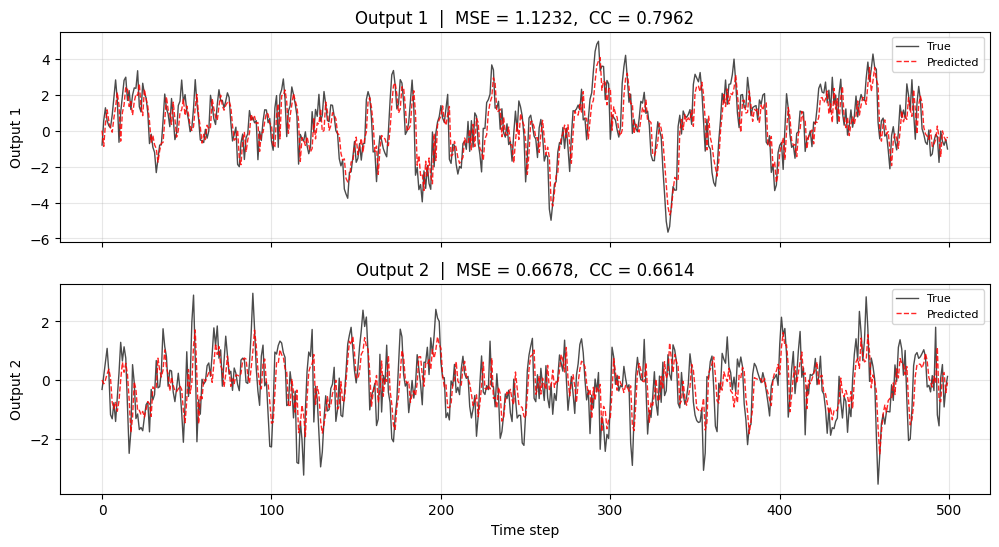

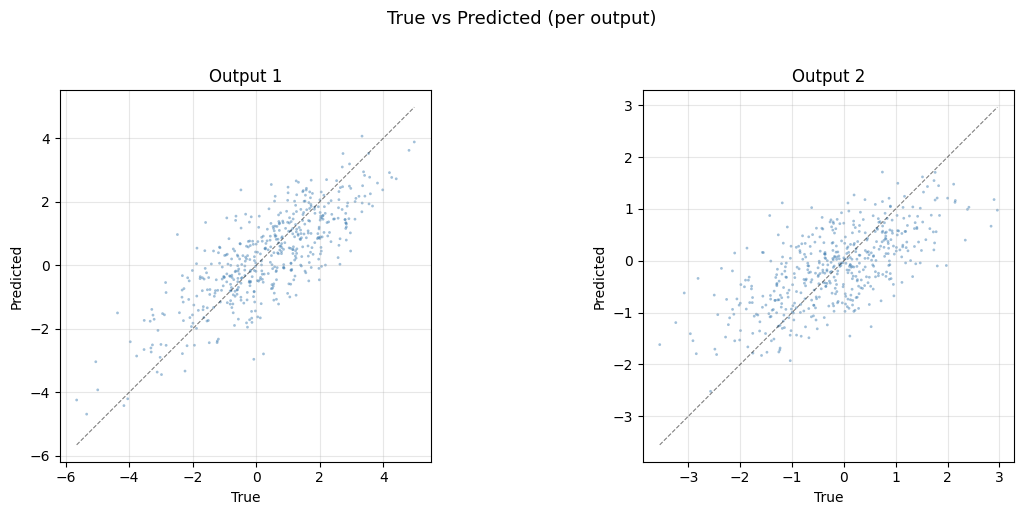

Per-output metrics:
  Output 1: MSE = 1.1232, MAE = 0.8561, CC = 0.7962
  Output 2: MSE = 0.6678, MAE = 0.6497, CC = 0.6614


In [81]:
# Cell 4: Visualization of predictions vs ground truth
import matplotlib.pyplot as plt

# Predict on test data
Y_pred = model.predict(U_test)

# Create figure with subplots for each output dimension
fig, axes = plt.subplots(model.n_outputs, 1, figsize=(12, 3 * model.n_outputs), sharex=True)
if model.n_outputs == 1:
    axes = [axes]

time = np.arange(len(Y_test))

for i in range(model.n_outputs):
    ax = axes[i]
    ax.plot(time, Y_test[:, i], 'k-', linewidth=1.0, alpha=0.7, label='True')
    ax.plot(time, Y_pred[:, i], 'r--', linewidth=1.0, alpha=0.85, label='Predicted')
    ax.set_ylabel(f'Output {i+1}')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

    # Compute per-output metrics
    mse_i = np.mean((Y_test[:, i] - Y_pred[:, i]) ** 2)
    cc_i = np.corrcoef(Y_test[:, i], Y_pred[:, i])[0, 1]
    ax.set_title(f'Output {i+1}  |  MSE = {mse_i:.4f},  CC = {cc_i:.4f}')

axes[-1].set_xlabel('Time step')

# Add a scatter plot comparing true vs predicted for all outputs
fig2, axes2 = plt.subplots(1, model.n_outputs, figsize=(6 * model.n_outputs, 5))
if model.n_outputs == 1:
    axes2 = [axes2]

for i in range(model.n_outputs):
    ax = axes2[i]
    ax.scatter(Y_test[:, i], Y_pred[:, i], s=4, alpha=0.5, c='steelblue', edgecolors='none')
    # y = x line
    lims = [min(Y_test[:, i].min(), Y_pred[:, i].min()),
            max(Y_test[:, i].max(), Y_pred[:, i].max())]
    ax.plot(lims, lims, 'k--', linewidth=0.8, alpha=0.5)
    ax.set_xlabel('True')
    ax.set_ylabel('Predicted')
    ax.set_title(f'Output {i+1}')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

fig2.suptitle('True vs Predicted (per output)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Summary stats
print("Per-output metrics:")
for i in range(model.n_outputs):
    mse_i = np.mean((Y_test[:, i] - Y_pred[:, i]) ** 2)
    mae_i = np.mean(np.abs(Y_test[:, i] - Y_pred[:, i]))
    cc_i  = np.corrcoef(Y_test[:, i], Y_pred[:, i])[0, 1]
    print(f"  Output {i+1}: MSE = {mse_i:.4f}, MAE = {mae_i:.4f}, CC = {cc_i:.4f}")